In [62]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
pd.set_option("display.max_columns", None)

In [64]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [65]:
userInputDataRaw = loadDataFromFile("User:Previous experiments")
timeSeriesData = loadDataFromFile("Data:Previous experiments")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 237 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/User:Previous experiments.json
/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 474273 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/Data:Previous experiments.json


In [66]:
userInputDataRaw

,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,epoch_ms,timestamp_local
0,{'$oid': '6863fe54cdf92819382e6866'},StartingExperiment,{'$date': 1751383636513},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,1751383636513,2025-07-01 15:27:16.513
1,{'$oid': '686408456a2505a88d9b0665'},InsertingSourcePollutant,{'$date': 1751386181232},ExperimentState,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,1751386181232,2025-07-01 16:09:41.232
2,{'$oid': '686409746a2505a88d9b087a'},RemovingSourcePollutant,{'$date': 1751386484742},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,1751386484742,2025-07-01 16:14:44.742
3,{'$oid': '6865537ae30f2ab561c621a8'},StartingExperiment,{'$date': 1751470970240},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,1751470970240,2025-07-02 15:42:50.240
4,{'$oid': '68655761e30f2ab561c629a2'},InsertingSourcePollutant,{'$date': 1751471969827},ExperimentState,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,1751471969827,2025-07-02 15:59:29.827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,{'$oid': '68adfc02ac4a03c9fe12c5d2'},InsertingSourcePollutant,{'$date': 1756232706584},ExperimentState,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,1756232706584,2025-08-26 18:25:06.584
233,{'$oid': '68adfdf0ac4a03c9fe12cc82'},RemovingSourcePollutant,{'$date': 1756233200196},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,1756233200196,2025-08-26 18:33:20.196
234,{'$oid': '68ae0039ac4a03c9fe12d41e'},StartingExperiment,{'$date': 1756233785024},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,1756233785024,2025-08-26 18:43:05.024
235,{'$oid': '68ae0111ac4a03c9fe12d71e'},InsertingSourcePollutant,{'$date': 1756234001710},ExperimentState,on,None,None,0.60,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,NaN,0.60,None,None,1756234001710,2025-08-26 18:46:41.710


In [67]:
timeSeriesData

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-07-01 15:27:18,NaN,1.480697,NaN
1,2025-07-01 15:27:19,NaN,NaN,1.430472
2,2025-07-01 15:27:21,NaN,1.469428,NaN
3,2025-07-01 15:27:22,NaN,NaN,1.441322
4,2025-07-01 15:27:24,NaN,1.476243,NaN
...,...,...,...,...
474268,2025-08-26 18:55:45,NaN,NaN,947.767300
474269,2025-08-26 18:55:46,29.33235,NaN,NaN
474270,2025-08-26 18:55:48,NaN,81.105730,NaN
474271,2025-08-26 18:55:48,NaN,NaN,513.575400


In [68]:
userInputData = userInputDataRaw.drop(columns=["_id","timestamp","epoch_ms","userInputCategory","pollutant-type","quantity-used"])

In [69]:
userInputData["timestamp_local"] = pd.to_datetime(userInputData["timestamp_local"])  # ensure datetime
userInputData["timestamp_local"] = userInputData["timestamp_local"].dt.floor("s")

In [70]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp_local
0,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,None,None,2025-07-01 15:27:16
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41
2,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,None,None,2025-07-01 16:14:44
3,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,None,None,2025-07-02 15:42:50
4,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06
233,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,None,None,2025-08-26 18:33:20
234,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,None,None,2025-08-26 18:43:05
235,InsertingSourcePollutant,on,None,None,0.60,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,NaN,0.60,None,None,2025-08-26 18:46:41


In [71]:
userInputDataTemp = userInputData[userInputData["experimentState"].isin(["NoSourcePollutantInserted","InsertingSourcePollutant"])].copy()

userInputDataTemp["timestamp StartingExperiment"] = userInputData["timestamp_local"].shift(1).loc[userInputData.index]
userInputDataTemp["timestamp EndingExperiment"]= userInputData["timestamp_local"].shift(-1).loc[userInputData.index]
userInputData =userInputDataTemp
userInputData = userInputData.reset_index(drop = True)
userInputData = userInputData.rename(columns={"timestamp_local":"timestamp InsertingSource"})



In [72]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment
0,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52
2,InsertingSourcePollutant,on,None,None,0.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31
3,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.85,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11
4,InsertingSourcePollutant,on,None,None,1.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.35,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.60,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.00,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16
77,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20


In [73]:
dict_of_timeseries = {}
for index, row in userInputData.iterrows():
    #get datetime
    start = row["timestamp StartingExperiment"]
    turning_point = row["timestamp InsertingSource"]
    end = row["timestamp EndingExperiment"]
    #Grab data
    particular_experiment = timeSeriesData[(timeSeriesData["timestamp"] >= start) & (timeSeriesData["timestamp"] <= end)]
    particular_experiment = particular_experiment.sort_values(by = ["timestamp"],ignore_index = True)
    dict_of_timeseries[index] = particular_experiment



In [74]:
example_df = dict_of_timeseries[10]
example_df

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-07-19 16:04:22,NaN,0.513479,NaN
1,2025-07-19 16:04:24,NaN,NaN,0.508068
2,2025-07-19 16:04:25,NaN,0.518917,NaN
3,2025-07-19 16:04:27,NaN,NaN,0.504020
4,2025-07-19 16:04:28,NaN,0.521494,NaN
...,...,...,...,...
699,2025-07-19 16:21:49,NaN,2.617029,NaN
700,2025-07-19 16:21:51,NaN,NaN,5.626779
701,2025-07-19 16:21:52,NaN,2.615562,NaN
702,2025-07-19 16:21:54,NaN,NaN,5.601505


In [75]:
for index, row in userInputData.iterrows():
    particular_experiment =  dict_of_timeseries[index]

    #make the dataframe from multiple columns to have the data for each sensor to just one column
    particular_experiment = particular_experiment.melt(
        id_vars=["timestamp"], 
        value_vars=[
            "Id=0:BME680:breathVocEquivalent",
            "Id=1:BME680:breathVocEquivalent",
            "Id=2:BME680:breathVocEquivalent"
        ],
        var_name="sensors", 
        value_name="VOC"
    )
    particular_experiment = particular_experiment.dropna(ignore_index = True)

    particular_experiment = particular_experiment.sort_values(by = ["timestamp"],ignore_index = True)
    dict_of_timeseries[index] = particular_experiment

In [76]:
example_df = dict_of_timeseries[10]
example_df.head(20)

,timestamp,sensors,VOC
0,2025-07-19 16:04:22,Id=1:BME680:breathVocEquivalent,0.513479
1,2025-07-19 16:04:24,Id=2:BME680:breathVocEquivalent,0.508068
2,2025-07-19 16:04:25,Id=1:BME680:breathVocEquivalent,0.518917
3,2025-07-19 16:04:27,Id=2:BME680:breathVocEquivalent,0.504020
4,2025-07-19 16:04:28,Id=1:BME680:breathVocEquivalent,0.521494
5,2025-07-19 16:04:30,Id=2:BME680:breathVocEquivalent,0.509921
6,2025-07-19 16:04:31,Id=1:BME680:breathVocEquivalent,0.518891
7,2025-07-19 16:04:33,Id=2:BME680:breathVocEquivalent,0.507465
8,2025-07-19 16:04:34,Id=1:BME680:breathVocEquivalent,0.514929
9,2025-07-19 16:04:36,Id=2:BME680:breathVocEquivalent,0.509477


In [77]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment
0,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52
2,InsertingSourcePollutant,on,None,None,0.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31
3,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.85,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11
4,InsertingSourcePollutant,on,None,None,1.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.35,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.60,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.00,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16
77,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20


In [78]:
for index, row in userInputData.iterrows():
#Now, we only have timestamps based of whenever the sensor took the value, but we want to have times 
    # Get full range of seconds from start to end timestamp
    particular_experiment =  dict_of_timeseries[index]
    start = row["timestamp StartingExperiment"]
    turning_point = row["timestamp InsertingSource"]

    end = row["timestamp EndingExperiment"]
    full_time_range = pd.date_range(start, end, freq="s")
    
    all_sensors = particular_experiment["sensors"].unique()
    particular_experiment["timestamp"] = pd.to_datetime(particular_experiment["timestamp"])
    
    full_index = pd.MultiIndex.from_product([full_time_range, all_sensors], names=["timestamp", "sensors"])
    extended_particular_experiment= pd.DataFrame(index=full_index).reset_index()
    particular_experiment = extended_particular_experiment.merge(particular_experiment, on=["timestamp", "sensors"], how="left",suffixes=["",None])
    particular_experiment["after_insertion"] = particular_experiment["timestamp"] > turning_point
    particular_experiment["original_value"] = pd.notna(particular_experiment["VOC"])
    dict_of_timeseries[index] = particular_experiment


In [79]:
userInputData["date of experiment"] = userInputData["timestamp EndingExperiment"].apply(lambda x:x.date())

In [80]:
example_df = dict_of_timeseries[10]
example_df

,timestamp,sensors,VOC,after_insertion,original_value
0,2025-07-19 16:04:22,Id=1:BME680:breathVocEquivalent,0.513479,False,True
1,2025-07-19 16:04:22,Id=2:BME680:breathVocEquivalent,NaN,False,False
2,2025-07-19 16:04:23,Id=1:BME680:breathVocEquivalent,NaN,False,False
3,2025-07-19 16:04:23,Id=2:BME680:breathVocEquivalent,NaN,False,False
4,2025-07-19 16:04:24,Id=1:BME680:breathVocEquivalent,NaN,False,False
...,...,...,...,...,...
2104,2025-07-19 16:21:53,Id=2:BME680:breathVocEquivalent,NaN,True,False
2105,2025-07-19 16:21:54,Id=1:BME680:breathVocEquivalent,NaN,True,False
2106,2025-07-19 16:21:54,Id=2:BME680:breathVocEquivalent,5.601505,True,True
2107,2025-07-19 16:21:55,Id=1:BME680:breathVocEquivalent,2.590167,True,True


In [81]:



for index, row in userInputData.iterrows():
    
        particular_experiment =  dict_of_timeseries[index]

        particular_experiment["VOC"] = (
            particular_experiment
            .groupby("sensors")["VOC"]
            .transform(lambda s: s.interpolate(method = "cubic"))
        )
        dict_of_timeseries[index] = particular_experiment
        # Compute z-scores for the selected columns
        #particular_experiment.dropna(inplace=True,ignore_index = True)

            
            


In [82]:
example_df = dict_of_timeseries[10]
example_df

,timestamp,sensors,VOC,after_insertion,original_value
0,2025-07-19 16:04:22,Id=1:BME680:breathVocEquivalent,0.513479,False,True
1,2025-07-19 16:04:22,Id=2:BME680:breathVocEquivalent,NaN,False,False
2,2025-07-19 16:04:23,Id=1:BME680:breathVocEquivalent,0.515345,False,False
3,2025-07-19 16:04:23,Id=2:BME680:breathVocEquivalent,NaN,False,False
4,2025-07-19 16:04:24,Id=1:BME680:breathVocEquivalent,0.517211,False,False
...,...,...,...,...,...
2104,2025-07-19 16:21:53,Id=2:BME680:breathVocEquivalent,5.629334,True,False
2105,2025-07-19 16:21:54,Id=1:BME680:breathVocEquivalent,2.601317,True,False
2106,2025-07-19 16:21:54,Id=2:BME680:breathVocEquivalent,5.601505,True,True
2107,2025-07-19 16:21:55,Id=1:BME680:breathVocEquivalent,2.590167,True,True


In [83]:
userInputData["actual timestamp StartingExperiment"] = np.nan
userInputData["actual timestamp EndingExperiment"] = np.nan

for index, row in userInputData.iterrows():
    particular_experiment =  dict_of_timeseries[index]
    #print(f"index:{index}")
    first_timestamps =  particular_experiment[particular_experiment["VOC"].notna()].groupby("sensors", as_index=False)["timestamp"].min()
   # print(f"first_timestamps:{first_timestamps}")
    
    last_timestamps =  particular_experiment[particular_experiment["VOC"].notna()].groupby("sensors", as_index=False)["timestamp"].max()
    #print(f"last_timestamps:{last_timestamps}")

   

    start = first_timestamps["timestamp"].max()
    userInputData.at[index,"actual timestamp StartingExperiment"] = start
    end = last_timestamps["timestamp"].min()
    userInputData.at[index,"actual timestamp EndingExperiment"] = end

    
 
            
    particular_experiment =   particular_experiment.loc[particular_experiment["timestamp"].between(start, end,inclusive ="both")]
        
    particular_experiment =particular_experiment.reset_index(drop=True)
   
    dict_of_timeseries[index] = particular_experiment


/tmp/ipykernel_13602/1795509057.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-07-01 15:27:19' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  userInputData.at[index,"actual timestamp StartingExperiment"] = start
/tmp/ipykernel_13602/1795509057.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-07-01 16:14:42' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  userInputData.at[index,"actual timestamp EndingExperiment"] = end


In [84]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment
0,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50
2,InsertingSourcePollutant,on,None,None,0.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31
3,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.85,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10
4,InsertingSourcePollutant,on,None,None,1.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.35,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.60,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.00,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14
77,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18


In [85]:
example_df = dict_of_timeseries[10]
example_df

,timestamp,sensors,VOC,after_insertion,original_value
0,2025-07-19 16:04:24,Id=1:BME680:breathVocEquivalent,0.517211,False,False
1,2025-07-19 16:04:24,Id=2:BME680:breathVocEquivalent,0.508068,False,True
2,2025-07-19 16:04:25,Id=1:BME680:breathVocEquivalent,0.518917,False,True
3,2025-07-19 16:04:25,Id=2:BME680:breathVocEquivalent,0.503896,False,False
4,2025-07-19 16:04:26,Id=1:BME680:breathVocEquivalent,0.520305,False,False
...,...,...,...,...,...
2098,2025-07-19 16:21:52,Id=2:BME680:breathVocEquivalent,5.635052,True,False
2099,2025-07-19 16:21:53,Id=1:BME680:breathVocEquivalent,2.609777,True,False
2100,2025-07-19 16:21:53,Id=2:BME680:breathVocEquivalent,5.629334,True,False
2101,2025-07-19 16:21:54,Id=1:BME680:breathVocEquivalent,2.601317,True,False


In [86]:


for index, row in userInputData.iterrows():
    particular_experiment =  dict_of_timeseries[index]

    print(f"index is {index}")
    particular_experiment =  dict_of_timeseries[index]
    
    # keep only rows with VOC present
    filtered = particular_experiment[particular_experiment["VOC"].notna()]
    min_timestamp_for_each_sensor = (
        filtered
        .groupby("sensors", as_index=False)["timestamp"]
        .min()
        )
    print(f"min value")
    print(min_timestamp_for_each_sensor)
    first_timestamp_to_keep = min_timestamp_for_each_sensor["timestamp"].max()
    
    particular_experiment = particular_experiment[particular_experiment["timestamp"] >= first_timestamp_to_keep]
    
    print(f"max value")
    max_timestamp_for_each_sensor =(
        filtered
        .groupby("sensors", as_index=False)["timestamp"]
        .max()
        )
    print(max_timestamp_for_each_sensor)
 

index is 0
min value
                           sensors           timestamp
0  Id=1:BME680:breathVocEquivalent 2025-07-01 15:27:19
1  Id=2:BME680:breathVocEquivalent 2025-07-01 15:27:19
max value
                           sensors           timestamp
0  Id=1:BME680:breathVocEquivalent 2025-07-01 16:14:42
1  Id=2:BME680:breathVocEquivalent 2025-07-01 16:14:42
index is 1
min value
                           sensors           timestamp
0  Id=1:BME680:breathVocEquivalent 2025-07-02 15:42:50
1  Id=2:BME680:breathVocEquivalent 2025-07-02 15:42:50
max value
                           sensors           timestamp
0  Id=1:BME680:breathVocEquivalent 2025-07-02 16:04:50
1  Id=2:BME680:breathVocEquivalent 2025-07-02 16:04:50
index is 2
min value
                           sensors           timestamp
0  Id=1:BME680:breathVocEquivalent 2025-07-03 12:30:25
1  Id=2:BME680:breathVocEquivalent 2025-07-03 12:30:25
max value
                           sensors           timestamp
0  Id=1:BME680:breathVocEqu

for index, row in userInputData.iterrows():
    
        particular_experiment =  dict_of_timeseries[index]

        particular_experiment["cutted_VOC"] = particular_experiment["VOC"]
        particular_experiment["zscore"] =np.nan
        sensors = particular_experiment["sensors"].unique()
        for sensor in all_sensors:
            inner_mask = particular_experiment["sensors"] == sensor
            
            outer_mask = particular_experiment.loc[inner_mask, "VOC"] 
            sensor_full_name = "z-score=3 for "+sensor
            particular_experiment.loc[inner_mask,"zscore"] = stats.zscore(outer_mask)
            userInputData.at[index,sensor_full_name] = find_value_VOC_withz_score_equals_3(outer_mask)
            
            
            particular_experiment.loc[ 
                inner_mask & (particular_experiment["zscore"] > 3)
                ,"cutted_VOC"] =userInputData.at[index,sensor_full_name] 
            
            
        dict_of_timeseries[index] = particular_experiment

In [87]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment
0,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50
2,InsertingSourcePollutant,on,None,None,0.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31
3,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.85,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10
4,InsertingSourcePollutant,on,None,None,1.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.35,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.60,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.00,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14
77,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18


In [88]:
index = 6
particular_experiment =  dict_of_timeseries[index]
sensors = particular_experiment["sensors"].unique()

print(index)
for sensor in sensors:
    mask = particular_experiment["sensors"]==sensor
    masked_data = particular_experiment.loc[mask]
    diffs = masked_data["timestamp"].diff()
    expected_step = diffs.mode()[0]
    broken_rows = masked_data["timestamp"][diffs != expected_step]
    print("Rows breaking frequency:\n", broken_rows)
    print()

6
Rows breaking frequency:
 0      2025-07-14 18:30:00
1177   2025-07-14 18:39:48
2372   2025-07-14 18:49:45
5094   2025-07-14 19:12:24
Name: timestamp, dtype: datetime64[ns]

Rows breaking frequency:
 1      2025-07-14 18:30:00
2500   2025-07-14 18:50:48
4229   2025-07-14 19:05:12
4608   2025-07-14 19:08:21
Name: timestamp, dtype: datetime64[ns]



In [89]:
for index, row in userInputData.iterrows():

    particular_experiment =  dict_of_timeseries[index]
    particular_experiment = particular_experiment.drop_duplicates()
    dict_of_timeseries[index] = particular_experiment

In [90]:
userInputData["time taken total"] = np.nan

for index, row in userInputData.iterrows():

    particular_experiment =  dict_of_timeseries[index]
    sensors = particular_experiment["sensors"].unique()
    for sensor in sensors:
        
        mask = particular_experiment["sensors"]==sensor
        #masked_data = particular_experiment.loc[mask]
        
        start = particular_experiment.loc[mask]["timestamp"].min()
        end = particular_experiment.loc[mask]["timestamp"].max()
        
        duration = end - start
        
        timeline = pd.timedelta_range(start="0s", end=duration, freq="S")
        particular_experiment.loc[mask,"datetime_timestamp"] = particular_experiment.loc[mask,"timestamp"]
        particular_experiment.loc[mask,"timestamp"] = timeline
        particular_experiment.loc[mask,"seconds"] = timeline.total_seconds()
        userInputData.at[index,"time taken total"] = duration    
    dict_of_timeseries[index] =   particular_experiment
       


/tmp/ipykernel_13602/3667341802.py:17: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  timeline = pd.timedelta_range(start="0s", end=duration, freq="S")
/tmp/ipykernel_13602/3667341802.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TimedeltaIndex(['0 days 00:00:00', '0 days 00:00:01', '0 days 00:00:02',
                '0 days 00:00:03', '0 days 00:00:04', '0 days 00:00:05',
                '0 days 00:00:06', '0 days 00:00:07', '0 days 00:00:08',
                '0 days 00:00:09',
                ...
                '0 days 00:47:14', '0 days 00:47:15', '0 days 00:47:16',
                '0 days 00:47:17', '0 days 00:47:18', '0 days 00:47:19',
                '0 days 00:47:20', '0 days 00:47:21', '0 days 00:47:22',
                '0 days 00:47:23'],
               dtype='timedelta64[ns]', length=2844, freq='s')' has dtype incompatible with dateti

In [91]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total
0,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23
1,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00
2,InsertingSourcePollutant,on,None,None,0.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.95,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06
3,InsertingSourcePollutant,on,None,None,0.95,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.85,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30
4,InsertingSourcePollutant,on,None,None,1.40,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.35,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.60,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.00,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33
77,InsertingSourcePollutant,on,None,None,0.70,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50


In [92]:
 dict_of_timeseries[10]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,0.517211,False,False,2025-07-19 16:04:24,0.0
1,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,0.508068,False,True,2025-07-19 16:04:24,0.0
2,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,0.518917,False,True,2025-07-19 16:04:25,1.0
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,0.503896,False,False,2025-07-19 16:04:25,1.0
4,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,0.520305,False,False,2025-07-19 16:04:26,2.0
...,...,...,...,...,...,...,...
2098,0 days 00:17:28,Id=2:BME680:breathVocEquivalent,5.635052,True,False,2025-07-19 16:21:52,1048.0
2099,0 days 00:17:29,Id=1:BME680:breathVocEquivalent,2.609777,True,False,2025-07-19 16:21:53,1049.0
2100,0 days 00:17:29,Id=2:BME680:breathVocEquivalent,5.629334,True,False,2025-07-19 16:21:53,1049.0
2101,0 days 00:17:30,Id=1:BME680:breathVocEquivalent,2.601317,True,False,2025-07-19 16:21:54,1050.0


In [93]:
userInputData["timestamp InsertingSource timedelta"] = np.nan
userInputData["timestamp InsertingSource seconds"] = np.nan

for index, row in userInputData.iterrows():

    particular_experiment =  dict_of_timeseries[index]
    sensors = particular_experiment["sensors"].unique()

    for sensor in sensors:
        
        mask = particular_experiment["sensors"]==sensor
        #print(masker)

        start = particular_experiment.loc[mask,:]["timestamp"].min()
       # print(start)
        end = particular_experiment.loc[mask,:]["timestamp"].max()
        #print(end)
       # print(sensor)
        
        mask = (particular_experiment["sensors"] == sensor) & (particular_experiment["after_insertion"] == True)
        filtered = particular_experiment.loc[mask]
        #print(first_index)
        if not filtered.empty:
            first_index = filtered.index[0]
            insertion_time = filtered.at[first_index, "timestamp"]
        
            userInputData.at[index, "timestamp InsertingSource timedelta"] = insertion_time
            userInputData.at[index, "timestamp InsertingSource seconds"] = insertion_time.total_seconds()
            userInputData.at[index, "time taken after insertion"] = (
                userInputData.at[index, "time taken total"] - insertion_time
    )

    dict_of_timeseries[index] =   particular_experiment
    

/tmp/ipykernel_13602/161819636.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0 days 00:42:23' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  userInputData.at[index, "timestamp InsertingSource timedelta"] = insertion_time


In [94]:
userInputData.loc[:,["front-wall","side-right-wall","back-wall","side-left-wall"]] = np.floor(userInputData.loc[:,["front-wall","side-right-wall","back-wall","side-left-wall"]]*10)/10

In [95]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20,0 days 00:07:04,424.0,0 days 00:14:16
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18,0 days 00:05:17,317.0,0 days 00:11:01
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33,0 days 00:19:31,1171.0,0 days 00:22:02
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50,0 days 00:28:39,1719.0,0 days 00:08:11


In [96]:
room_length = 4.0
room_width = 3.7
userInputData["x axis"] = np.nan
userInputData["y axis"] = np.nan
#front is max,back is zero,right is max,left is zero
def find_x_axis(x,room_width):
    from_right = None
    from_left = None

    #return NaN either if numbers at the position columns are negative or above room width
    if (x["side-right-wall"]<0 and x["side-right-wall"]> room_width) or (x["side-left-wall"]< 0 and x["side-left-wall"]> room_width) or (pd.isna(x["side-right-wall"]) and pd.isna(x["side-left-wall"])):
        x["x axis"] = np.nan
        return x["x axis"] 
    if pd.notna(x["side-right-wall"]):
       from_right = room_width - x["side-right-wall"]
    if pd.notna(x["side-left-wall"]):
       from_left = x["side-left-wall"]
      
    if  from_right is not None and from_left is not None:
        if from_right == from_left:
            x["x axis"] = from_right
        else:
            x["x axis"] = np.nan
          

    elif pd.notna(x["side-left-wall"]):
    
        x["x axis"] = from_left

    elif pd.notna(x["side-right-wall"]):
        x["x axis"] = from_right
    return  x["x axis"]

def find_y_axis(x,room_length):
    from_right = None
    from_left = None

    #return NaN either if numbers at the position columns are negative or above room width
    if (x["front-wall"]<0 and x["front-wall"]> room_length) or (x["back-wall"]< 0 and x["back-wall"]> room_length) or (pd.isna(x["front-wall"]) and pd.isna(x["back-wall"])):
        x["y axis"] = np.nan
        return x["y axis"] 
    if pd.notna(x["front-wall"]):
       from_right = room_length - x["front-wall"]
    if pd.notna(x["back-wall"]):
       from_left = x["back-wall"]
    if from_right is not None and from_left is not None:
        if from_right == from_left:
            x["y axis"] = from_right
        else:
            x["y axis"] = np.nan
            
    elif pd.notna(x["back-wall"]):
    
        x["y axis"] = from_left

    elif pd.notna(x["front-wall"]):
        x["y axis"] = from_right

    return  x["y axis"]

userInputData["x axis"] = userInputData.apply(lambda x:find_x_axis(x,room_width),axis=1)
userInputData["y axis"] = userInputData.apply(lambda x:find_y_axis(x,room_length),axis=1)

In [97]:
userInputData.head(30)

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00,0.9,3.1
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20,0.9,3.1
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58,0.9,3.6
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02,1.8,3.1
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29,1.3,2.6
5,InsertingSourcePollutant,None,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.7,None,None,2025-07-12 22:57:57,2025-07-12 22:31:25,2025-07-12 23:02:13,2025-07-12,2025-07-12 22:34:03,2025-07-12 23:02:11,0 days 00:28:08,0 days 00:23:55,1435.0,0 days 00:04:13,1.7,3.1
6,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.7,None,None,2025-07-14 19:40:37,2025-07-14 17:50:04,2025-07-14 19:48:32,2025-07-14,2025-07-14 18:30:00,2025-07-14 19:20:03,0 days 00:50:03,NaN,NaN,NaT,1.7,2.6
7,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:04:09,2025-07-19 14:59:47,2025-07-19 15:08:10,2025-07-19,2025-07-19 14:59:49,2025-07-19 15:08:09,0 days 00:08:20,0 days 00:04:21,261.0,0 days 00:03:59,1.1,2.2
8,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:17:10,2025-07-19 15:14:13,2025-07-19 15:21:23,2025-07-19,2025-07-19 15:14:15,2025-07-19 15:21:21,0 days 00:07:06,0 days 00:02:56,176.0,0 days 00:04:10,1.1,2.2
9,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:30:49,2025-07-19 15:25:07,2025-07-19 15:44:28,2025-07-19,2025-07-19 15:25:09,2025-07-19 15:44:27,0 days 00:19:18,0 days 00:05:41,341.0,0 days 00:13:37,1.1,2.2


In [98]:
userInputData.loc[:, ["x axis", "y axis"]]

,x axis,y axis
0,0.9,3.1
1,0.9,3.1
2,0.9,3.6
3,1.8,3.1
4,1.3,2.6
...,...,...
74,0.6,0.6
75,2.7,0.8
76,1.0,1.8
77,2.8,3.3


In [99]:
#make the possibility of negative values to centralize the positions
room_length = room_length / 2
room_width = room_width / 2

#change the scale of x and y axis
if (userInputData["x axis"] >room_width ).any():
    userInputData["x axis"]  = userInputData["x axis"] - room_width
if (userInputData["y axis"] > room_length ).any():    
    userInputData["y axis"] = userInputData["y axis"]  - room_length

In [100]:
userInputData.loc[:, ["x axis", "y axis"]]

,x axis,y axis
0,-0.95,1.1
1,-0.95,1.1
2,-0.95,1.6
3,-0.05,1.1
4,-0.55,0.6
...,...,...
74,-1.25,-1.4
75,0.85,-1.2
76,-0.85,-0.2
77,0.95,1.3


In [101]:
userInputData["room"].unique()

array(['Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55',
       'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1',
       'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90'],
      dtype=object)

In [102]:
pos_id0 = 'position of Id=0:BME680:breathVocEquivalent'
pos_id1 = 'position of Id=1:BME680:breathVocEquivalent'
pos_id2 = 'position of Id=2:BME680:breathVocEquivalent'
pos_id_all = [pos_id0,pos_id1,pos_id2]
room_positions = {
    'Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55' : {
        pos_id1 +"-x axis" : 0.85 ,
        pos_id1 +"-y axis" : room_length - 0.95,
        pos_id2+"-x axis" : 1.55 ,
        pos_id2+  "-y axis" : room_length - 0.95
              
    },
        
    'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1' : {
        pos_id1+"-x axis" : 1.2 ,
        pos_id1+"-y axis" : 0.6,
        pos_id2+"-x axis" : 1.1 ,
        pos_id2+"-y axis" : room_length - 0.9
   
    },      
        
    'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90' : {
        
        pos_id0+"-x axis" : 0.9, 
        pos_id0+"-y axis" : room_length - 0.8,
        
        pos_id1+"-x axis" : 0.9,
        pos_id1+"-y axis" : room_length - 0.8,
        
        pos_id2+"-x axis" : 0.9,
        pos_id2+"-y axis" : room_length - 0.8
     }    
}
room_positions

{'Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55': {'position of Id=1:BME680:breathVocEquivalent-x axis': 0.85,
  'position of Id=1:BME680:breathVocEquivalent-y axis': 1.05,
  'position of Id=2:BME680:breathVocEquivalent-x axis': 1.55,
  'position of Id=2:BME680:breathVocEquivalent-y axis': 1.05},
 'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1': {'position of Id=1:BME680:breathVocEquivalent-x axis': 1.2,
  'position of Id=1:BME680:breathVocEquivalent-y axis': 0.6,
  'position of Id=2:BME680:breathVocEquivalent-x axis': 1.1,
  'position of Id=2:BME680:breathVocEquivalent-y axis': 1.1},
 'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90': {'position of Id=0:BME680:breathVocEquivalent-x axis': 0.9,
  'position of Id=0:BME680:breathVocEquivalent-y axis': 1.2,
  'position of Id=1:BME680:breathVocEquivalent-x axis': 0.9,
  'position of Id=1:BME680:breathVocEquivalent-y axis': 1.2,
  'position of Id=2:BME680:breathVocEquivalent-x axis': 0.9,
  'position of Id=2:BME680:breathVocEquivalent

In [103]:
for pos_id in pos_id_all:
    userInputData[pos_id+"-x axis"] = np.nan
    userInputData[pos_id+"-y axis"] = np.nan
    


for room,sensor_positions in room_positions.items():
   # print(f"room:{room}")
    outer_mask = userInputData["room"] == room
  #  print(f"sensor_positions:{sensor_positions}")
    for sensor_position,value  in sensor_positions.items():
 
        userInputData.loc[outer_mask,sensor_position] = value

In [104]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58,-0.95,1.6,NaN,NaN,0.85,1.05,1.55,1.05
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02,-0.05,1.1,NaN,NaN,0.85,1.05,1.55,1.05
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29,-0.55,0.6,NaN,NaN,0.85,1.05,1.55,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20,0 days 00:07:04,424.0,0 days 00:14:16,-1.25,-1.4,0.9,1.2,0.90,1.20,0.90,1.20
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18,0 days 00:05:17,317.0,0 days 00:11:01,0.85,-1.2,0.9,1.2,0.90,1.20,0.90,1.20
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33,0 days 00:19:31,1171.0,0 days 00:22:02,-0.85,-0.2,0.9,1.2,0.90,1.20,0.90,1.20
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50,0 days 00:28:39,1719.0,0 days 00:08:11,0.95,1.3,0.9,1.2,0.90,1.20,

In [105]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58,-0.95,1.6,NaN,NaN,0.85,1.05,1.55,1.05
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02,-0.05,1.1,NaN,NaN,0.85,1.05,1.55,1.05
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29,-0.55,0.6,NaN,NaN,0.85,1.05,1.55,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20,0 days 00:07:04,424.0,0 days 00:14:16,-1.25,-1.4,0.9,1.2,0.90,1.20,0.90,1.20
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18,0 days 00:05:17,317.0,0 days 00:11:01,0.85,-1.2,0.9,1.2,0.90,1.20,0.90,1.20
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33,0 days 00:19:31,1171.0,0 days 00:22:02,-0.85,-0.2,0.9,1.2,0.90,1.20,0.90,1.20
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50,0 days 00:28:39,1719.0,0 days 00:08:11,0.95,1.3,0.9,1.2,0.90,1.20,

In [106]:
userInputData.loc[:, ["x axis", "y axis"]]

,x axis,y axis
0,-0.95,1.1
1,-0.95,1.1
2,-0.95,1.6
3,-0.05,1.1
4,-0.55,0.6
...,...,...
74,-1.25,-1.4
75,0.85,-1.2
76,-0.85,-0.2
77,0.95,1.3


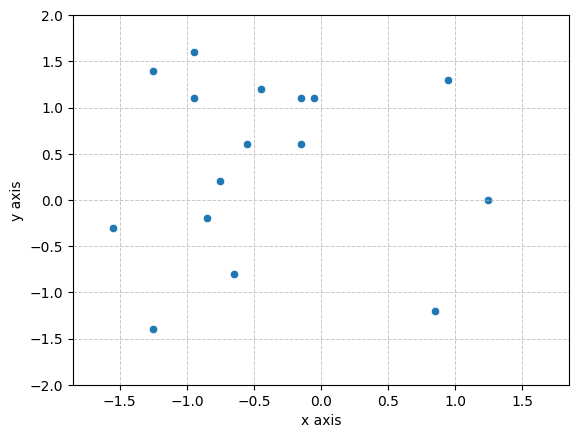

In [107]:
# Example max values (you can replace with user input)
room_length = 2.0
room_width = 1.85 

# Create scatterplot
sns.scatterplot(
    data=userInputData.loc[:, ["x axis", "y axis"]],
    x="x axis",
    y="y axis"
)

# Set axis limits
plt.xlim(-room_width, room_width)
plt.ylim(-room_length, room_length)

# Add grid
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)

plt.show()

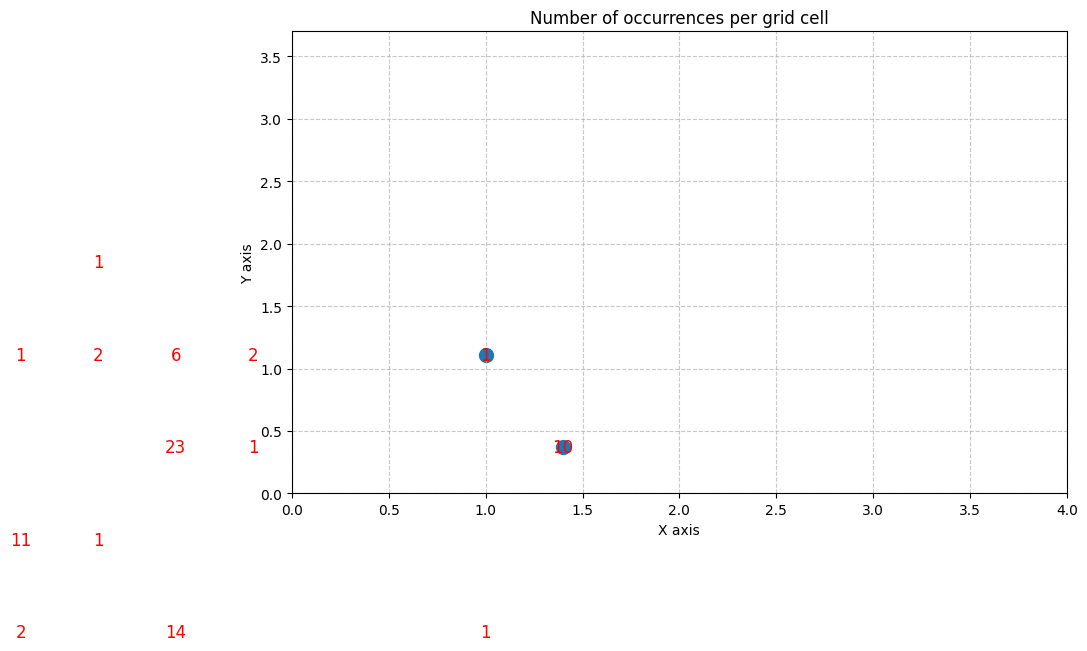

In [108]:
# User-defined max x and y, and grid size
max_x = 4
max_y = 3.7  
x_bins = 10  # number of grid cells along x
y_bins = 5   # number of grid cells along y

# Extract x and y
x = userInputData["x axis"]
y = userInputData["y axis"]

# Bin the points
x_bin = np.floor(x / (max_x / x_bins))
y_bin = np.floor(y / (max_y / y_bins))

# Combine bins into a DataFrame
df_bins = pd.DataFrame({'x_bin': x_bin, 'y_bin': y_bin})

# Count occurrences at each grid cell
counts = df_bins.value_counts().reset_index()
counts.columns = ['x_bin', 'y_bin', 'count']

# Convert bin numbers back to grid positions (center of cell)
counts['x_pos'] = (counts['x_bin'] + 0.5) * (max_x / x_bins)
counts['y_pos'] = (counts['y_bin'] + 0.5) * (max_y / y_bins)

# Plot
plt.figure(figsize=(10,6))
plt.scatter(counts['x_pos'], counts['y_pos'], s=100)  # s=100 sets point size

# Add count labels
for i, row in counts.iterrows():
    plt.text(row['x_pos'], row['y_pos'], int(row['count']),
             color='red', fontsize=12, ha='center', va='center')

plt.xlim(0, max_x)
plt.ylim(0, max_y)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Number of occurrences per grid cell")
plt.show()

In [109]:
from matplotlib.ticker import FuncFormatter

def createTheTitleForTheFigure(experiment_number):
    date = userInputData.iloc[experiment_number]["timestamp InsertingSource"].date()
    
    if ((experiment_number > 0 )):
        previous_date = userInputData.iloc[experiment_number - 1]["timestamp InsertingSource"].date()
        if (date != previous_date):
            print("........................................................\n\n")
    
    title = "Experiment at row " + str(experiment_number)+ "At "+date.strftime("%Y-%m-%d")+ f" BME680:breathVocEquivalent.\n"
    if (userInputData.iloc[experiment_number]["experimentState"] == "InsertingSourcePollutant"):
        title= title + "at the pollution source position to be "
        if (pd.isna(userInputData.iloc[experiment_number]['front-wall'])==False):
           title =title + f"{userInputData.iloc[experiment_number]['front-wall']} meters from the front wall, "
        if (pd.isna(userInputData.iloc[experiment_number]['back-wall'])==False):
           title =title +f"{userInputData.iloc[experiment_number]['back-wall']} meters from the back wall, "
        if (pd.isna(userInputData.iloc[experiment_number]['side-right-wall'])==False):
           title =title+ f"{userInputData.iloc[experiment_number]['side-right-wall']} meters from the side right wall, "
        if (pd.isna(userInputData.iloc[experiment_number]['side-left-wall'])==False):
           title =title+ f"{userInputData.iloc[experiment_number]['side-left-wall']} meters from the side left wall, "
    elif (userInputData.iloc[experiment_number]["experimentState"] == "NoSourcePollutantInserted"):  
        title =title + "without source insertion.\n"
        
        
    
    title =title +"at the room:"+userInputData.iloc[experiment_number]["room"]+"\n"   
    title=title +"Στοιχεία για το μενωμένο πείραμα:"
    title= title+"Αντικείμενο που χρησιμοποιείται¨"+row["item-used"]+", "
    if (pd.isna(row["are-doors-opened"]) == False):
        title = title + "Οι πόρτες είναι ανοιχτές, "
    if (pd.isna(row["are-fans-on"]) == False):
        title = title + "Οι ανεμιστήρες είναι ενεργοποιημένοι, "
    if (pd.isna(row["are-people-inside"]) == False):
        title = title + "Βρίσκονται άνθρωποι μέσα, "
    if (pd.isna(row["are-windows-opened"]) == False):
        title = title + "Τα παράθυρα είναι ανοιχτά, "
    if (pd.isna(row["notes"])== False):
        title= title + "Σημειώσεις:"+ row["notes"]

    return title

def printData(dict_of_timeseries,plot_old_data = True):
    for experiment_number in dict_of_timeseries:
        particular_experiment =  dict_of_timeseries[experiment_number]
        
        title = createTheTitleForTheFigure(experiment_number)
            
       
        plt.figure(figsize=(18, 8))
        if plot_old_data:
            y_column_data = "VOC"
        else:
            y_column_data = "cutted_VOC"
            
        sns.lineplot(data=particular_experiment, x="seconds", y=y_column_data, hue="sensors")
        def format_seconds(x, _):
            return str(pd.to_timedelta(x, unit="s")).split()[-1]  # hh:mm:ss only
        plt.gca().xaxis.set_major_formatter(FuncFormatter(format_seconds))
        plt.xticks(rotation=45)
        
        plt.axvline(x=userInputData.at[experiment_number,"timestamp InsertingSource seconds"], color="red", linestyle="--", linewidth=2, label="timestamp of the inserting source")
        plt.title(title)
    
        plt.show()
    
        print("\n")

In [110]:
printData(dict_of_timeseries,plot_old_data = True)

KeyError: 'item-used'

In [111]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20,-0.95,1.1,NaN,NaN,0.85,1.05,1.55,1.05
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58,-0.95,1.6,NaN,NaN,0.85,1.05,1.55,1.05
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02,-0.05,1.1,NaN,NaN,0.85,1.05,1.55,1.05
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29,-0.55,0.6,NaN,NaN,0.85,1.05,1.55,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20,0 days 00:07:04,424.0,0 days 00:14:16,-1.25,-1.4,0.9,1.2,0.90,1.20,0.90,1.20
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18,0 days 00:05:17,317.0,0 days 00:11:01,0.85,-1.2,0.9,1.2,0.90,1.20,0.90,1.20
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33,0 days 00:19:31,1171.0,0 days 00:22:02,-0.85,-0.2,0.9,1.2,0.90,1.20,0.90,1.20
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50,0 days 00:28:39,1719.0,0 days 00:08:11,0.95,1.3,0.9,1.2,0.90,1.20,

In [112]:
dict_of_timeseries[6]

,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,0.500000,False,True,2025-07-14 18:30:00,0.0
1,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,0.500000,False,True,2025-07-14 18:30:00,0.0
2,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,0.500000,False,False,2025-07-14 18:30:01,1.0
3,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,0.500000,False,False,2025-07-14 18:30:01,1.0
4,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,0.500000,False,False,2025-07-14 18:30:02,2.0
...,...,...,...,...,...,...,...
6009,0 days 00:50:01,Id=2:BME680:breathVocEquivalent,18.846076,False,False,2025-07-14 19:20:01,3001.0
6010,0 days 00:50:02,Id=1:BME680:breathVocEquivalent,45.835785,False,False,2025-07-14 19:20:02,3002.0
6011,0 days 00:50:02,Id=2:BME680:breathVocEquivalent,18.729567,False,False,2025-07-14 19:20:02,3002.0
6012,0 days 00:50:03,Id=1:BME680:breathVocEquivalent,45.545510,False,True,2025-07-14 19:20:03,3003.0


In [113]:
#create a huge dataframe to save it 

# Combine into one DataFrame, keeping the dictionary key
big_df = pd.concat(dict_of_timeseries, names=["keys"])

# Reset index so the key becomes a column
big_df = big_df.reset_index(level="keys").reset_index(drop=True)

In [114]:
big_df

,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
0,0,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,1.472127,False,False,2025-07-01 15:27:19,0.0
1,0,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,1.430472,False,True,2025-07-01 15:27:19,0.0
2,0,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,1.468931,False,False,2025-07-01 15:27:20,1.0
3,0,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,1.434283,False,False,2025-07-01 15:27:20,1.0
4,0,0 days 00:00:02,Id=1:BME680:breathVocEquivalent,1.469428,False,True,2025-07-01 15:27:21,2.0
...,...,...,...,...,...,...,...,...
193488,78,0 days 00:12:40,Id=2:BME680:breathVocEquivalent,733.255283,True,False,2025-08-26 18:55:47,760.0
193489,78,0 days 00:12:40,Id=0:BME680:breathVocEquivalent,26.946737,True,False,2025-08-26 18:55:47,760.0
193490,78,0 days 00:12:41,Id=1:BME680:breathVocEquivalent,81.105730,True,True,2025-08-26 18:55:48,761.0
193491,78,0 days 00:12:41,Id=2:BME680:breathVocEquivalent,513.575400,True,True,2025-08-26 18:55:48,761.0


In [115]:
userInputData.columns

Index(['experimentState', 'are-doors-opened', 'are-people-inside',
       'are-windows-opened', 'front-wall', 'item-used', 'notes', 'room',
       'side-right-wall', 'back-wall', 'side-left-wall', 'are-fans-on',
       'no-source-located', 'timestamp InsertingSource',
       'timestamp StartingExperiment', 'timestamp EndingExperiment',
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', 'time taken total',
       'timestamp InsertingSource timedelta',
       'timestamp InsertingSource seconds', 'time taken after insertion',
       'x axis', 'y axis',
       'position of Id=0:BME680:breathVocEquivalent-x axis',
       'position of Id=0:BME680:breathVocEquivalent-y axis',
       'position of Id=1:BME680:breathVocEquivalent-x axis',
       'position of Id=1:BME680:breathVocEquivalent-y axis',
       'position of Id=2:BME680:breathVocEquivalent-x axis',
       'position of Id=2:BME680:breathVocEquivalent-y axis'],
      dtype='obj

In [116]:
def saveDataIntoDataFolder(data,data_file_name):
    script_dir = Path().resolve().parent
    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (data_file_name + ".json")
    with open(file_path, 'w') as file:
        if isinstance(data, pd.DataFrame):
            print("It's a DataFrame")
            if  data.empty:
                print("No data to save.")
            else:
                data.to_json(file_path, orient='records', lines=False)             
                print(f"Data saved to {file_path}")

        else:  
            print("It's NOT a DataFrame.")    
            if not data:
                print("No data to save.")
            else:    
                json.dump(data, file)
                print(f"Data saved to {file_path}")


saveDataIntoDataFolder(userInputData,"UserPrevious experiments-preprocessed")
saveDataIntoDataFolder(big_df,"Data:Previous experiments-preprocessed")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
It's a DataFrame
Data saved to /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/UserPrevious experiments-preprocessed.json
/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
It's a DataFrame
Data saved to /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/Data:Previous experiments-preprocessed.json
